In [1]:
import pandas as pd

df = pd.read_csv(
    "../data/customer_churn.csv"
)

df.head()

,frequency,monetary,avg_order_value,category_count,avg_review_score,avg_delivery_days,total_freight_paid,recency_days,customer_tenure_days,cluster,customer_segment,clv,churn,customer_segment_encoded
0,1,141.90,141.90,1,5.0,6.0,12.00,115,115,2,Active Customers,44.708219,0,0
1,1,27.19,27.19,1,4.0,3.0,8.29,118,118,2,Active Customers,8.790192,0,0
2,1,86.22,86.22,1,3.0,25.0,17.22,541,541,0,Inactive Customers,127.794575,1,2
3,1,43.62,43.62,1,4.0,20.0,17.63,325,325,0,Inactive Customers,38.839726,0,2
4,1,196.89,196.89,1,5.0,13.0,16.89,292,292,0,Inactive Customers,157.512000,0,2


In [2]:
df["monetary"].describe()

count     95419.000000
mean        213.970410
std         645.760476
min           9.590000
25%          63.990000
50%         113.330000
75%         203.300000
max      109312.640000
Name: monetary, dtype: float64

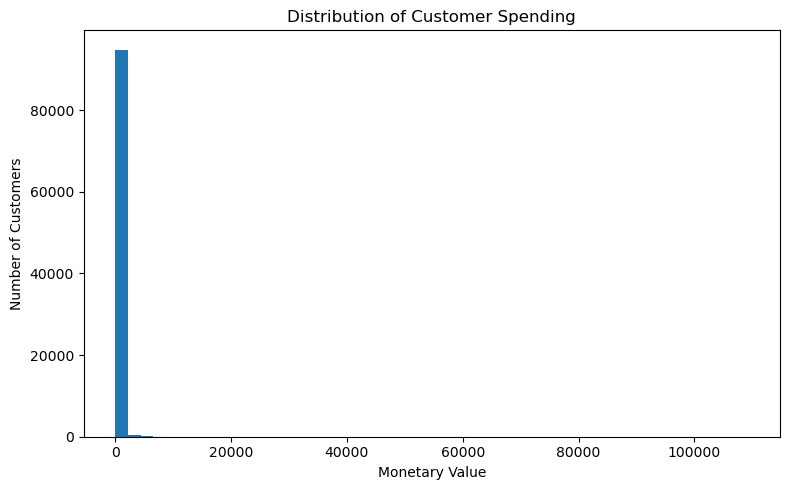

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df["monetary"],
    bins=50
)

plt.title(
    "Distribution of Customer Spending"
)

plt.xlabel(
    "Monetary Value"
)

plt.ylabel(
    "Number of Customers"
)

plt.tight_layout()

plt.savefig(
    "../visualizations/monetary_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [6]:
print(
    df["monetary"].skew()
)

# Highly right skewed

68.17593784234055


In [5]:
import numpy as np

df["monetary_log"] = np.log1p(
    df["monetary"]
)

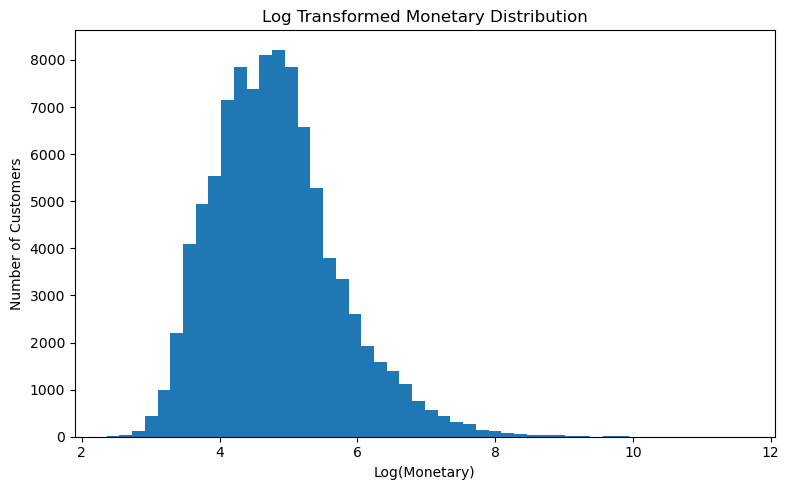

In [7]:
plt.figure(figsize=(8,5))

plt.hist(
    df["monetary_log"],
    bins=50
)

plt.title(
    "Log Transformed Monetary Distribution"
)

plt.xlabel(
    "Log(Monetary)"
)

plt.ylabel(
    "Number of Customers"
)

plt.tight_layout()

plt.savefig(
    "../visualizations/log_monetary_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [8]:
features = [
    "frequency",
    "avg_order_value",
    "category_count",
    "avg_review_score",
    "avg_delivery_days",
    "total_freight_paid",
    "customer_segment_encoded"
]

In [9]:
X = df[features]

y = df["monetary_log"]

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
y_pred = lr.predict(
    X_test
)

In [13]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = mse**0.5

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.4264111777792658
RMSE: 0.6333881608591512
R2: 0.5148356115664363


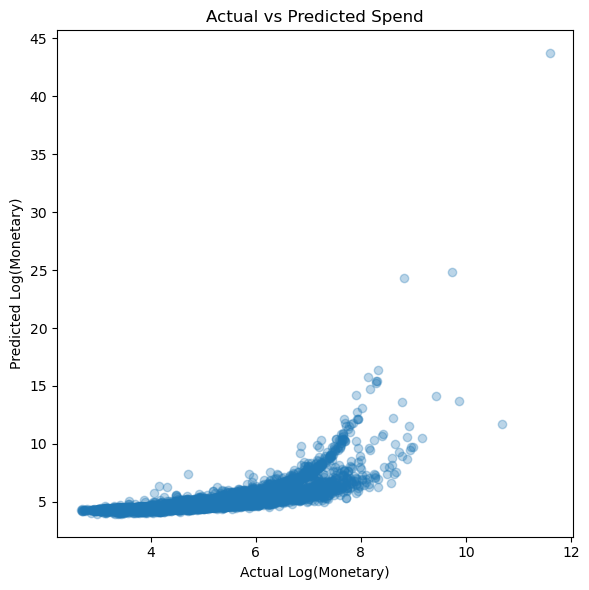

In [14]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

plt.title(
    "Actual vs Predicted Spend"
)

plt.xlabel(
    "Actual Log(Monetary)"
)

plt.ylabel(
    "Predicted Log(Monetary)"
)

plt.tight_layout()

plt.savefig(
    "../visualizations/spend_actual_vs_predicted_lr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
results = pd.DataFrame({
    "Metric":[
        "MAE",
        "RMSE",
        "R2"
    ],
    "Value":[
        mae,
        rmse,
        r2
    ]
})

results

,Metric,Value
0,MAE,0.426411
1,RMSE,0.633388
2,R2,0.514836


In [16]:
import joblib

joblib.dump(
    lr,
    "../models/spend_prediction_lr.pkl"
)

['../models/spend_prediction_lr.pkl']